## Esquinas
Harris - Shi/Tomassi

In [16]:
import numpy as np
import cv2 as cv
import supervision as sv

In [17]:
# Cargamos la imagen a procesar
img = cv.imread('chessboard2.png')
#img = cv.imread('bloques.png')

# La transformamos en escala de grises
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
gray = np.float32(gray)

#### Harris

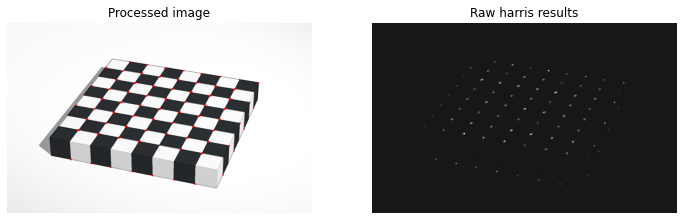

In [18]:
# Detector de esquinas de Harris (imagen, bloque, apertura del filtro de Sobel, k)

dst = cv.cornerHarris(gray, blockSize=2, ksize=3, k=0.06)

# El resultado se dilata para marcar las esquinas (solo para mostrar)
dst = cv.dilate(dst, None)

# El umbral óptimo dependerá de la imagen
img_out=img.copy()
img_out[dst > 0.1 * dst.max()]=[0,0,255]

# Muestro la imagen y la salida del detector
sv.plot_images_grid(
    images=[img_out, dst], 
    titles=['Processed image', 'Raw harris results'], 
    grid_size=(1, 2))


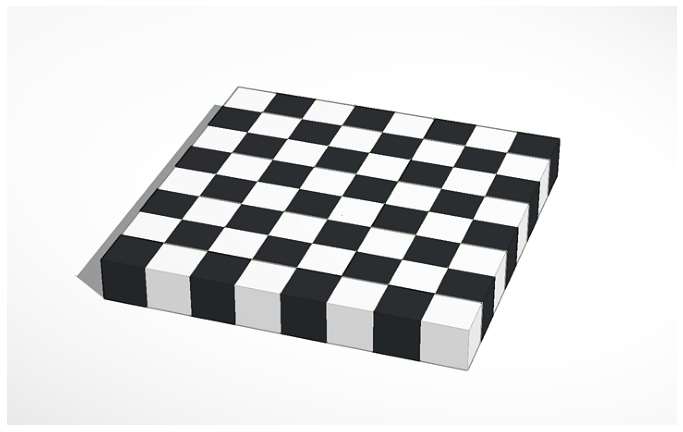

In [19]:
# Agregamos subpixel

# Encontrar esquinas de Harris
dst = cv.cornerHarris(gray, blockSize=2, ksize=3, k=0.06)
dst = cv.dilate(dst,None)
ret, dst = cv.threshold(dst,0.01*dst.max(),255,0)
dst = np.uint8(dst)

# Encontrar Centroides
ret, labels, stats, centroids = cv.connectedComponentsWithStats(dst)

# definir el criterio para detención y refinación de esquinas
criteria = (cv.TERM_CRITERIA_MAX_ITER + cv.TERM_CRITERIA_EPS, 100, 0.001)

# Para evitar singularidades en la matriz de harris se puede aplicar una zeroZone
# dentro de la ventana de busqueda en la cual los pixeles no van a ser a ser analizados

corners = cv.cornerSubPix(gray, np.float32(centroids), winSize=(5,5), zeroZone=(-1,-1), criteria=criteria)

# Dibujar esquinas
res = np.hstack((centroids,corners))
res = np.int32(res)
img[res[:,1],res[:,0]]=[0,0,255]
img[res[:,3],res[:,2]] = [0,255,0]
sv.plot_image(img)

#### Shi - Tomassi

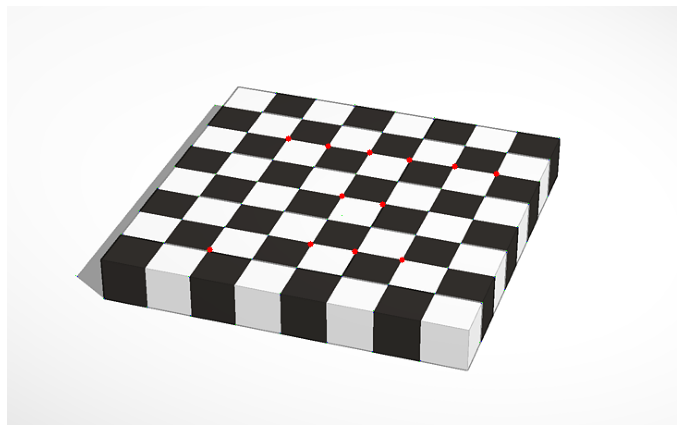

In [22]:
img_out=img.copy()

# Detector de esquinas de Shi-Tomassi (imagen, Nmax, calidad, distancia mínima)
corners = cv.goodFeaturesToTrack(
    image=gray, 
    maxCorners=98, 
    qualityLevel=0.8, 
    minDistance=10)
corners = np.int32(corners)
for i in corners:
    x,y = i.ravel()
    cv.circle(img_out,(x,y),3,255,-1)
    
img_out = cv.cvtColor(img_out,cv.COLOR_BGR2RGB)
sv.plot_image(img_out)